## 1 · Import Required Libraries

Import LangChain, LangGraph, Groq LLM, PostgreSQL utilities, and other dependencies.

In [15]:
import os
import json
import re
from typing import TypedDict, Optional, Literal
from dotenv import load_dotenv

from langchain_groq import ChatGroq
from langchain_community.utilities import SQLDatabase
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph, END, START
from langgraph.constants import START, END

load_dotenv()

True

## 2 · Define State and Initialize LLM

Create a TypedDict state with fields for question, sql_query, schema, results, answer, error_log, retry_count, and is_relevant flag. Initialize Groq LLM with API key.

In [16]:
class AgentState(TypedDict):
    question: str
    sql_query: Optional[str]
    schema: Optional[str]
    results: Optional[list]
    answer: Optional[str]
    error_log: list
    retry_count: int
    is_relevant: bool

GROQ_API_KEY = os.getenv("GROQ_API_KEY")
llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0,
    api_key=GROQ_API_KEY
)

DB_USER = "admin"
DB_PASSWORD = "admin%40123"
DB_HOST = "100.90.162.48"
DB_PORT = "5432"
DB_NAME = "chicago_crime_new"
DB_URI = f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"

db = SQLDatabase.from_uri(DB_URI)
print(f"✓ Database connected: {db.dialect}")

✓ Database connected: postgresql


In [17]:
db.get_table_names()

['community_area_names', 'crime_incidents', 'district_names', 'ward_names']

## 3 · Create Relevance Checker Node

Validates if the question is database-related using the LLM. Returns state with is_relevant flag set accordingly.

In [18]:
def relevance_checker(state: AgentState) -> AgentState:
    question = state["question"].lower().strip()
    
    query_action_verbs = {
        "how many", "how often", "what are the", "list", "show", 
        "find", "get", "count", "total", "sum", "average", "top", "most", "least",
        "rank", "filter", "between", "after", "before", "during", "in the year", "percentage"
    }
    
    data_context_words = {
        "crime", "chicago", "crimes", "report", "reported", "database", "table",
        "records", "data", "district", "year", "date", "type", "arrest", "victim",
        "incidents", "cases", "statistics", "breakdown", "distribution"
    }
    
    irrelevant_patterns = [
        (r"what\s+is\s+\d+\s*[\+\-\*/]\s*\d+", "math expression"),
        (r"what is the meaning", "meaning of life"),
        (r"^what is\s+\w+\s*\?*\s*$", "generic what is"),
        (r"^define\s+", "define"),
        (r"^explain\s+", "explain"),
        (r"^tell me about\s+", "tell me about"),
        (r"who (are|is|was|were)", "who question"),
        (r"when (are|is|was|were)", "when question"),
        (r"why (are|is|was|were)", "why question"),
    ]
    
    invalid_data_questions = [
        (r"what\s+is\s+(chicago_crime|the chicago crime|the crimes|the database|the table)(?:\s|$|\?)", "non-specific data"),
    ]
    
    for pattern, reason in invalid_data_questions:
        if re.search(pattern, question, re.IGNORECASE):
            state["is_relevant"] = False
            state["error_log"].append(f"Relevance: {reason}")
            break
    else:
        for pattern, reason in irrelevant_patterns:
            if re.search(pattern, question, re.IGNORECASE):
                state["is_relevant"] = False
                state["error_log"].append(f"Relevance: {reason}")
                break
        else:
            has_action_verb = any(verb in question for verb in query_action_verbs)
            has_data_context = any(word in question for word in data_context_words)
            
            if has_action_verb and has_data_context:
                state["is_relevant"] = True
                state["error_log"].append("Relevance: Approved")
                return state
            
            state["is_relevant"] = False
            state["error_log"].append("Relevance: Rejected - missing action verb or data context")
    
    if not state["is_relevant"]:
        messages = [
            SystemMessage(content="You are a helpful assistant. The user's question is not related to a database or data analysis. Politely explain that their question is outside your scope and is not answerable using the database. Be concise but friendly."),
            HumanMessage(content=f"User question: {state['question']}")
        ]
        response = llm.invoke(messages)
        state["answer"] = response.content
    
    return state

## 4 · Create Schema Fetcher Node

Retrieves table schemas from PostgreSQL using SQLDatabase utility and stores them in state.

In [19]:
def schema_fetcher(state: AgentState) -> AgentState:
    try:
        tables = db.get_usable_table_names()
        schema = db.get_table_info()
        state["schema"] = schema
    except Exception as e:
        state["error_log"].append(f"Schema fetch error: {str(e)}")
        state["schema"] = ""
    return state

## 5 · Create Query Generator Node

Generates SQL queries based on the schema and question with a system prompt that prevents DML statements (UPDATE, DELETE, DROP).

In [20]:
def query_generator(state: AgentState) -> AgentState:
    system_prompt = """You are a PostgreSQL expert. Write a precise SELECT query for the question and call sql_db_query.
Use only column names that exist in the provided schema.
Use only the table names that are relevant to the question, as indicated by the schema tool results.
Never modify data (no INSERT / UPDATE / DELETE / DROP).
Make sure to use proper joins, group by, order by, and limit clauses as needed to answer the question accurately and concisely.
Create new columns as needed with WITH statements or subqueries, but avoid unnecessary complexity.

CRITICAL RULES:
- CASE SENSITIVITY: This database is case-sensitive for identifiers.
- You MUST enclose ALL column names and table names in double quotes (e.g., "Year", "Primary Type") exactly as they appear in the schema.
- Use double quotes for string literals (e.g., WHERE "Primary Type" = 'THEFT').
- Limit results to at most 3 rows unless the user asks otherwise.
- Only select the columns that are relevant to the question.
- Order results by a relevant column when it helps the answer.
- NEVER issue DML statements (INSERT, UPDATE, DELETE, DROP, etc.).
- Return ONLY the SQL query without explanations or markdown formatting.
- If the question cannot be answered with a SELECT query, respond with: INVALID_REQUEST"""

    schema = state.get("schema", "")
    question = state["question"]
    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content="Schema:\n" + schema + "\n\nQuestion: " + question)
    ]
    response = llm.invoke(messages)
    sql_query = response.content.strip()

    if "INVALID_REQUEST" in sql_query:
        state["error_log"].append("Generator: Request cannot be fulfilled with SELECT query")
        state["sql_query"] = None
    else:
        state["sql_query"] = sql_query

    return state

## 6 · Create Query Validator Node

Validates SQL syntax using dry-run execution. Routes to Query Runner if valid or back to Query Generator if invalid (max 3 retries).

In [21]:
def query_validator(state: AgentState) -> AgentState:
    if not state.get("sql_query"):
        state["error_log"].append("Validator: No SQL query to validate")
        return state
    
    try:
        query = state["sql_query"]
        if re.search(r'\b(UPDATE|DELETE|DROP|INSERT|ALTER)\b', query, re.IGNORECASE):
            state["error_log"].append(f"Validator: DML statement detected in query: {query}")
            state["sql_query"] = None
            return state
        
        result = db.run(f"EXPLAIN {query}", fetch="all")
        state["error_log"].append(f"Validator: Query syntax is valid")
    except Exception as e:
        error_msg = f"Validator: SQL syntax error: {str(e)}"
        state["error_log"].append(error_msg)
        state["sql_query"] = None
    
    return state

def should_retry_query(state: AgentState) -> Literal["query_generator", "query_runner", "answer_synthesizer"]:
    if not state.get("sql_query"):
        state["retry_count"] += 1
        if state["retry_count"] >= 3:
            state["error_log"].append("Max retries reached (3). Ending query generation.")
            state["answer"] = "I was unable to generate a valid SQL query after 3 attempts. Please rephrase your question."
            return "answer_synthesizer"
        return "query_generator"
    return "query_runner"

## 7 · Create Query Runner Node

Executes the SQL query against PostgreSQL and stores results in state.

In [22]:
def query_runner(state: AgentState) -> AgentState:
    try:
        result = db.run(state["sql_query"], fetch="all")
        state["results"] = result if isinstance(result, list) else [result]
        state["error_log"].append(f"Runner: Query executed successfully. Rows: {len(state['results'])}")
    except Exception as e:
        state["error_log"].append(f"Runner: Query execution error: {str(e)}")
        state["results"] = []
    
    return state

## 8 · Create Answer Synthesizer Node

Converts SQL results into a natural language response using the LLM.

In [23]:
def answer_synthesizer(state: AgentState) -> AgentState:
    if state.get("answer"):
        return state
    
    if not state.get("results"):
        state["answer"] = "No results found for your query."
        return state
    
    results_str = json.dumps(state["results"][:10], indent=2)
    messages = [
        SystemMessage(content="You are a data analyst. Provide a clear, concise natural language summary of the SQL query results."),
        HumanMessage(content=f"Question: {state['question']}\n\nSQL Results:\n{results_str}\n\nProvide a summary.")
    ]
    response = llm.invoke(messages)
    state["answer"] = response.content
    
    return state

## 9 · Build StateGraph with Conditional Edges

Construct the StateGraph with all nodes and define conditional edges:
- Relevance Checker → Schema Fetcher (if relevant) OR END
- Query Validator → Query Runner (if valid) OR Query Generator (max 3 retries)

In [24]:
def should_continue_after_relevance(state: AgentState) -> Literal["schema_fetcher", END]:
    return "schema_fetcher" if state.get("is_relevant") else END

graph = StateGraph(AgentState)

graph.add_node("relevance_checker", relevance_checker)
graph.add_node("schema_fetcher", schema_fetcher)
graph.add_node("query_generator", query_generator)
graph.add_node("query_validator", query_validator)
graph.add_node("query_runner", query_runner)
graph.add_node("answer_synthesizer", answer_synthesizer)

graph.add_edge(START, "relevance_checker")
graph.add_conditional_edges("relevance_checker", should_continue_after_relevance)
graph.add_edge("schema_fetcher", "query_generator")
graph.add_edge("query_generator", "query_validator")
graph.add_conditional_edges("query_validator", should_retry_query)
graph.add_edge("query_runner", "answer_synthesizer")
graph.add_edge("answer_synthesizer", END)

app = graph.compile()
print("✓ StateGraph compiled successfully")

✓ StateGraph compiled successfully


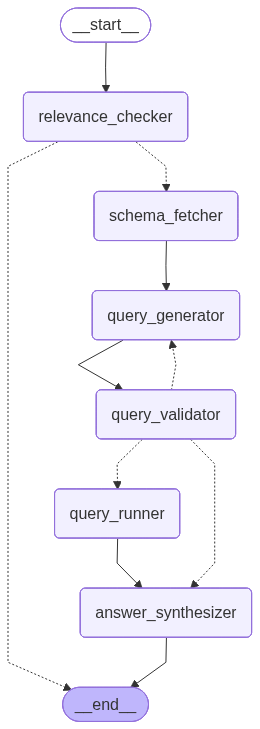

In [25]:
app

## 10 · Compile and Test the Agent

Compile the graph using app.compile() and test with sample database queries to verify the workflow.

In [26]:
def run_agent(question: str):
    initial_state: AgentState = {
        "question": question,
        "sql_query": None,
        "schema": None,
        "results": None,
        "answer": None,
        "error_log": [],
        "retry_count": 0,
        "is_relevant": False
    }
    
    result = app.invoke(initial_state)
    
    print(f"\n{'='*60}")
    print(f"Question: {result['question']}")
    print(f"SQL Query: {result.get('sql_query', 'N/A')}")
    print(f"Results: {result.get('results', [])}")
    print(f"Answer: {result.get('answer', 'N/A')}")
    print(f"Error Log: {result.get('error_log', [])}")
    print(f"{'='*60}\n")
    
    return result

print("Agent functions ready. Use run_agent('your question') to test.")

Agent functions ready. Use run_agent('your question') to test.


In [27]:
result = run_agent("What is 2 + 2?")


Question: What is 2 + 2?
SQL Query: None
Results: None
Answer: I’m sorry, but that question isn’t something I can answer using the database tools I have available. If you have any queries related to data or analysis, I’d be happy to help!
Error Log: ['Relevance: math expression']



In [28]:
result = run_agent("what are the second most common crime types in each district in 2020?")


Question: what are the second most common crime types in each district in 2020?
SQL Query: WITH "crime_counts" AS (
    SELECT "DISTRICT" AS "district_id",
           "CRIME_TYPE" AS "crime_type",
           COUNT(*) AS "crime_count",
           DENSE_RANK() OVER (PARTITION BY "DISTRICT" ORDER BY COUNT(*) DESC) AS "rnk"
    FROM "crime_incidents"
    WHERE "YEAR" = 2020
    GROUP BY "DISTRICT", "CRIME_TYPE"
)
SELECT dn."district_name",
       cc."crime_type",
       cc."crime_count"
FROM "crime_counts" cc
JOIN "district_names" dn ON dn."district_id" = cc."district_id"
WHERE cc."rnk" = 2
ORDER BY dn."district_name"
LIMIT 3;
Results: ["[('Albany Park', 'BATTERY', 993), ('Austin', 'THEFT', 1111), ('Calumet', 'CRIMINAL DAMAGE', 1533)]"]
Answer: In 2020, the second‑most frequently reported crimes by district were:

- **Albany Park:** Battery, with 993 incidents.  
- **Austin:** Theft, with 1,111 incidents.  
- **Calumet:** Criminal damage, with 1,533 incidents.
Error Log: ['Relevance: Appr

In [29]:
result = run_agent("How many thefts were reported in lincoln park in 2021?")


Question: How many thefts were reported in lincoln park in 2021?
SQL Query: SELECT COUNT(*) AS "theft_count"
FROM "crime_incidents" ci
JOIN "community_area_names" ca ON ci."COMMUNITY_AREA" = ca."community_area_id"
WHERE ca."community_area_name" = 'Lincoln Park'
  AND ci."YEAR" = 2021
  AND ci."CRIME_TYPE" = 'THEFT';
Results: ['[(1160,)]']
Answer: In 2021, a total of **1,160 thefts** were reported in Lincoln Park.
Error Log: ['Relevance: Approved', 'Validator: SQL syntax error: (psycopg2.errors.UndefinedColumn) column "THEFT" does not exist\nLINE 3: WHERE "CRIME_TYPE" = "THEFT"\n                             ^\n\n[SQL: EXPLAIN SELECT COUNT(*) AS "theft_count"\nFROM "crime_incidents"\nWHERE "CRIME_TYPE" = "THEFT"\n  AND "YEAR" = 2021\n  AND "LOCATION_DESCRIPTION" ILIKE "LINCOLN PARK";]\n(Background on this error at: https://sqlalche.me/e/20/f405)', 'Validator: Query syntax is valid', 'Runner: Query executed successfully. Rows: 1']



In [30]:
result = run_agent("What are the high risk crimes ?")


Question: What are the high risk crimes ?
SQL Query: SELECT "CRIME_TYPE", COUNT(*) AS "incident_count"
FROM "crime_incidents"
WHERE "LOCATION_RISK_CATEGORY" = 'High Risk'
GROUP BY "CRIME_TYPE"
ORDER BY "incident_count" DESC
LIMIT 3;
Results: ["[('THEFT', 92602), ('MOTOR VEHICLE THEFT', 89205), ('BATTERY', 70304)]"]
Answer: The query identifies the three highest‑risk crime categories by incident count:

- **Theft** – 92,602 reported incidents  
- **Motor Vehicle Theft** – 89,205 reported incidents  
- **Battery** – 70,304 reported incidents  

These three offenses represent the most frequent (and thus highest‑risk) crimes in the dataset.
Error Log: ['Relevance: Approved', 'Validator: Query syntax is valid', 'Runner: Query executed successfully. Rows: 1']

